In [247]:
from relaqs.save_results import SaveResults
from relaqs.plot_data import *
from relaqs.api import gates
from relaqs.api.utils import *
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import MaxNLocator
from PIL import Image

In [29]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def training_figure(save_dir,
                    figure_title='',
                    plot_filename='plot',
                    perform_analysis=False,
                    save_plot=False):
    """Split into two publication‐quality figures:
       (a) 1–F (log scale) and (b) Sum of Rewards,
       with bold axis labels, darker ticks, and reduced x‐tick density.
       Automatically zooms y‐axis to the bulk of the data."""
    # ---------------------- Load data --------------------------------------
    df = pd.read_csv(os.path.join(save_dir, "env_data.csv"), header=0)
    fidelities  = df.iloc[:, 0].values
    rewards     = df.iloc[:, 1].values
    episode_ids = df.iloc[:, -1].values

    if perform_analysis:
        perform_action_analysis(df=df)

    # --------> Final per-episode values -----------------------------------
    final_inf = []
    sum_rw    = []
    ep, fid, acc = episode_ids[0], fidelities[0], rewards[0]
    for i in range(1, len(episode_ids)):
        if episode_ids[i] != ep:
            final_inf.append(1 - fid)
            sum_rw.append(acc)
            acc = 0
        ep, fid, acc = episode_ids[i], fidelities[i], acc + rewards[i]
    final_inf.append(1 - fid)
    sum_rw.append(acc)

    # ---------------------- Rolling averages --------------------------------
    window = 100
    def rolling_avg(x):
        return np.array([x[max(0, i-window):i+1].mean()
                         for i in range(len(x))])
    avg_inf = rolling_avg(np.array(final_inf))
    avg_rw  = rolling_avg(np.array(sum_rw))

    episodes = np.arange(len(final_inf))
    step     = 5

    # ----- Figure A: 1 - Fidelity (log scale) -----
    figA, axA = plt.subplots(figsize=(8, 5))
    axA.scatter(episodes[::step],
                final_inf[::step],
                s=5, alpha=0.3,
                color='tab:red')
    axA.plot(episodes,
             avg_inf,
             color='black',
             linewidth=1.5,
             )
    axA.set_yscale('log')

    # ---- Zoom y-axis to 1st–99th percentile of infidelity ----
    p_low, p_high = np.percentile(final_inf, [1, 99])
    axA.set_ylim(p_low, p_high)

    # Labels & styling
    # axA.set_xlabel('Episodes', fontsize=14)
    # axA.set_ylabel(r"$\epsilon$ (log scale)", fontsize=14)
    axA.tick_params(axis='both', which='major',
                    labelsize=16, width=1.5, length=6, color='black')
    axA.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
    # axA.legend(fontsize=11, loc='upper right')

    # figA.suptitle('Noisy One Qubit: SU(2)', fontsize=22, ha = 'center', fontweight='bold')
    plt.tight_layout()
    if save_plot:
        figA.savefig(os.path.join(save_dir, f"{plot_filename}_error.png"),
                     dpi=300)
        plt.close(figA)
    else:
        plt.show()

    # # ----- Figure B: Sum of Rewards -----
    figB, axB = plt.subplots(figsize=(8, 5))
    axB.scatter(episodes[::step],
                sum_rw[::step],
                s=5, alpha=0.3,
                color='tab:blue')
    axB.plot(episodes,
             avg_rw,
             color='black',
             linewidth=1.5,
             )

    # ---- Zoom y-axis to 1st–99th percentile of rewards ----
    r_low, r_high = np.percentile(sum_rw, [1, 99])
    axB.set_ylim(r_low, r_high)

    # axB.set_xlabel('Episodes', fontsize=14)
    # axB.set_ylabel('Sum of Rewards', fontsize=14)
    axB.tick_params(axis='both', which='major',
                    labelsize=16, width=1.5, length=6, color='black')
    axB.xaxis.set_major_locator(MaxNLocator(nbins=5, integer=True))
    # axB.yaxis.set_major_locator(MaxNLocator(nbins=4, integer=True))
    # axB.legend(fontsize=11, loc='upper left')

    # figB.suptitle('b)', fontsize=16, fontweight='bold', ha = 'left', x= 0.15)
    plt.tight_layout()
    if save_plot:
        figB.savefig(os.path.join(save_dir, f"{plot_filename}_reward.png"),
                     dpi=300)
        plt.close(figB)
    else:
        plt.show()

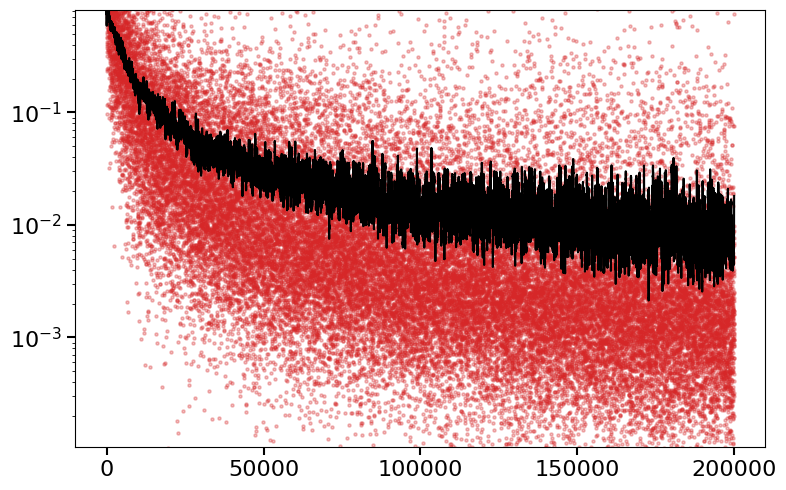

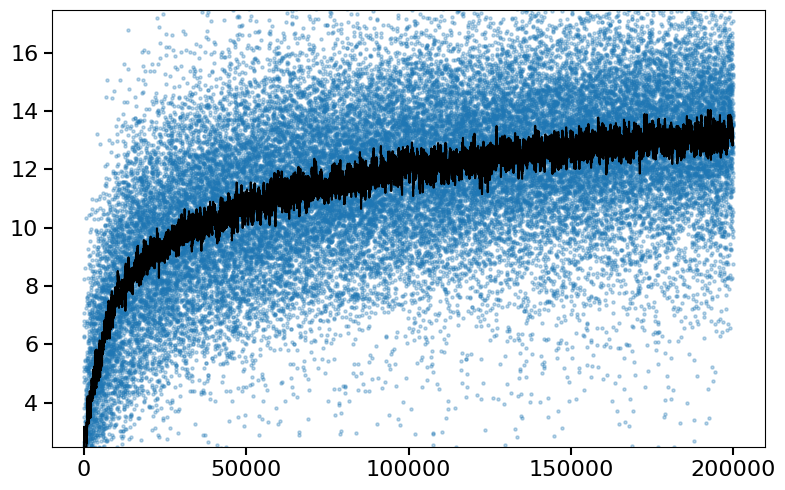

In [30]:
# training_figure('/Users/vishchaudhary/rl-repo/results/two-qubit gates/combined_training_I_CNOT/', save_plot=False, plot_filename='Training')
# training_figure('/Users/vishchaudhary/rl-repo/results/two-qubit gates/2025-07-02_22-45-26/', save_plot=False, plot_filename='Training')
training_figure('/Users/vishchaudhary/rl-repo/results/2025-03-26_03-13-38/', save_plot=False, plot_filename='Training')
# training_figure('/Users/vishchaudhary/rl-repo/results/two-qubit gates/2025-07-18_18-08-42/', save_plot=False, plot_filename='Training')

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def inference_distribution_figure(training_dir, inf_dir, save_plot=False):
    # ---------------------- Get Training Data  <--------------------------------------
    training_df = pd.read_csv(training_dir, header=0)
    training_fidelities      = np.array(training_df.iloc[:, 0])
    training_rewards         = np.array(training_df.iloc[:, 1])
    training_episode_ids     = np.array(training_df.iloc[:, -1])

    print("training_max fidelity: ", training_fidelities.max())
    print("training_max reward:   ", training_rewards.max())

    # --------> Final infidelity per episode (training) <--------
    training_final_fidelity_per_episode = []
    training_final_infelity_per_episode = []
    training_sum_of_rewards_per_episode = []

    current_episode_id = training_episode_ids[0]
    current_fidelity   = training_fidelities[0]
    current_reward_sum = training_rewards[0]
    for i in range(len(training_episode_ids)):
        if (training_episode_ids[i] != current_episode_id) or (i == len(training_episode_ids)-1):
            training_final_fidelity_per_episode.append(current_fidelity)
            training_final_infelity_per_episode.append(1 - current_fidelity)
            training_sum_of_rewards_per_episode.append(current_reward_sum)
            current_reward_sum = 0
        current_episode_id = training_episode_ids[i]
        current_fidelity   = training_fidelities[i]
        current_reward_sum += training_rewards[i]

    training_final_infelity_per_episode = np.array(training_final_infelity_per_episode)

    # ---------------------- Get Inference Data  <--------------------------------------
    inf_df        = pd.read_csv(inf_dir, header=0)
    inf_fidelities= np.array(inf_df.iloc[:, 0])
    inf_rewards   = np.array(inf_df.iloc[:, 1])
    inf_episode_ids = np.array(inf_df.iloc[:, -1])

    # Compute infidelity per episode (inference)
    inf_infidelity = np.array([1 - inf_fidelities[i] for i in range(len(inf_episode_ids))])

    print(f"\nMin training error: {training_final_infelity_per_episode.min()}")
    print(f"Max training error: {training_final_infelity_per_episode.max()}")
    print(f"Mean training error: {training_final_infelity_per_episode.mean()}")
    print(f"Median training error: {np.median(training_final_infelity_per_episode)}\n\n")

    print(f"\nMin infer error:      {inf_infidelity.min()}")
    print(f"Max infer error:      {inf_infidelity.max()}")
    print(f"Mean infer error: {inf_infidelity.mean()}")
    print(f"Median infer error: {np.median(inf_infidelity)}\n\n")

    # ---------------------- Build log‐spaced bins -------------------------
    all_inf = np.concatenate([training_final_infelity_per_episode, inf_infidelity])
    min_inf = max(all_inf.min(), 1e-12)
    max_inf = all_inf.max()
    bins    = np.logspace(np.log10(min_inf), np.log10(max_inf), 100)

    # ---------------------- Convert counts to percentages -----------------
    weights_tr  = np.ones_like(training_final_infelity_per_episode) / training_final_infelity_per_episode.size * 100
    weights_inf = np.ones_like(inf_infidelity)                 / inf_infidelity.size                 * 100

    # ---------------------- Plot histograms -------------------------------
    plt.figure(figsize=(8, 5))
    plt.hist(training_final_infelity_per_episode,
             bins=bins,
             weights=weights_tr,
             alpha=0.6,
             label='Training',
             color='tab:red',
             edgecolor='black')
    plt.hist(inf_infidelity,
             bins=bins,
             weights=weights_inf,
             alpha=0.6,
             label='Inference',
             color='tab:blue',
             edgecolor='black')

    plt.xscale('log')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    # plt.xlabel(r'$\epsilon$ (log scale)', fontsize=14, fontweight='bold')
    # plt.ylabel('Frequency (%)', fontsize=14, fontweight='bold')
    # plt.title('Distribution of Final Infidelity', fontsize=14, fontweight='bold')
    leg = plt.legend()               # no fontsize here…
    for txt in leg.get_texts():      # leg.get_texts() is a list of Text objects
        txt.set_fontsize(16)         # set each label’s font size
    plt.grid(True, which='both', ls=':', alpha=0.5)
    plt.tight_layout()

    if save_plot:
        out_dir = training_dir.rsplit('/', 1)[0]
        plt.savefig(f"{out_dir}/error_histogram_comparison.png",
                    dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

training_max fidelity:  0.9999996938560252
training_max reward:    21.540320896665445

Min training error: 3.06143974837525e-07
Max training error: 0.9999999367339723
Mean training error: 0.044052670118988176
Median training error: 0.0047098905781639555



Min infer error:      1.1069948567810073e-06
Max infer error:      0.9913069636623074
Mean infer error: 0.008777792186099566
Median infer error: 0.0011309987720685144




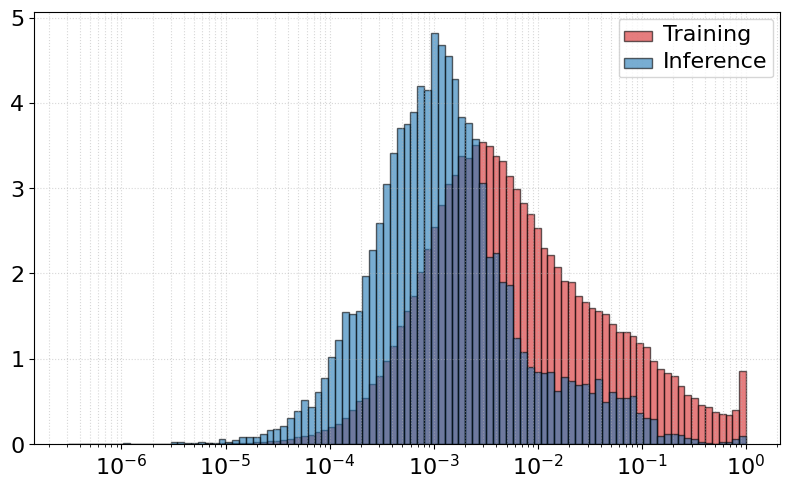

In [32]:
#ONE QUBIT
# inference_distribution_figure(training_dir='/Users/vishchaudhary/rl-repo/results/2025-03-26_03-13-38/env_data.csv', inf_dir='/Users/vishchaudhary/rl-repo/results/2025-03-26_03-13-38/RandomSU2/RandomSU2_env_data.csv')

##TWO QUBIT
inference_distribution_figure(training_dir='/Users/vishchaudhary/rl-repo/results/2025-03-26_03-13-38/env_data.csv',
                              inf_dir= '/Users/vishchaudhary/rl-repo/results/2025-03-26_03-13-38/RandomSU2/RandomSU2_env_data.csv', save_plot = False)

In [521]:
def infidelity_parser(path):
    df = pd.read_csv(path, header=0)
    fidelities   = df.iloc[:, 0].values
    fidelities = np.array(fidelities)
    error = 1.0 - fidelities

    return np.array(error)


def noise_std_plot_logerr(
    noise_aware, noise_unaware,
    y_min=1e-3, y_max=None,
    save_plot=False,
    save_dir=''
):
    """
    Plots final-infidelity vs noise-std with errorbars computed
    in log10-space (symmetric ±1σ in log domain).
    """
    def gather_log_stats(noise_dict, label):
        xs = np.array(sorted(noise_dict.keys()), float)
        y_means, y_errs = [], []
        print(f"\n{label} log-space stats:")
        for s in xs:
            infs = infidelity_parser(noise_dict[s])
            # steady = infs[-burn_in:] if len(infs)>= burn_in else infs
            logs = np.log10(infs)
            mu_log = logs.mean()
            sigma_log = logs.std(ddof=1)
            # convert back to linear domain
            y = 10**mu_log
            err_low  = y - 10**(mu_log - sigma_log)
            err_high = 10**(mu_log + sigma_log) - y
            print(f"  {s:.1e}: μ_log={mu_log:.3f}, σ_log={sigma_log:.3f}, "
                  f"y={y:.3e}, err_low={err_low:.3e}, err_high={err_high:.3e}")
            y_means.append(y)
            y_errs.append((err_low, err_high))
        errs = np.array(y_errs).T  # shape (2, N)
        return xs, np.array(y_means), errs

    x_a, y_a, err_a = gather_log_stats(noise_aware, "Noise-aware")
    x_u, y_u, err_u = gather_log_stats(noise_unaware, "Noise-unaware")

    if y_max is None:
        y_max = max((y_a + err_a[1]).max(), (y_u + err_u[1]).max()) * 1.2

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.errorbar(x_a, y_a, yerr=err_a,
                fmt='o-', color='tab:blue', ecolor='tab:blue',
                capsize=12, label='Noise-aware')
    ax.errorbar(x_u, y_u, yerr=err_u,
                fmt='s--', color='tab:red', ecolor='tab:red',
                capsize=12, label='Noise-unaware')

    ax.set_xscale('linear')
    ax.set_yscale('log')
    ax.set_ylim(y_min, y_max)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    # ax.set_xlabel(r"$\sigma_{\mathrm{detuning}}$ [MHz]", fontsize=16)
    # ax.set_ylabel(r'$\epsilon$ (log scale)', fontsize=16)
    ax.grid(True, which='both', linestyle=':', alpha=0.5)
    ax.legend(fontsize=10, loc='best')
    plt.tight_layout()

    if save_plot:
        plt.savefig(save_dir, dpi=300, bbox_inches='tight')
        plt.close(fig)
    else:
        plt.show()


# Example usage:
# noise_std_plot_logerr(noise_aware, noise_unaware)


Noise-aware log-space stats:
  1.0e+01: μ_log=-2.132, σ_log=0.816, y=7.382e-03, err_low=6.254e-03, err_high=4.092e-02
  2.0e+01: μ_log=-1.922, σ_log=0.654, y=1.196e-02, err_low=9.305e-03, err_high=4.190e-02
  4.0e+01: μ_log=-1.496, σ_log=0.727, y=3.195e-02, err_low=2.596e-02, err_high=1.384e-01
  6.0e+01: μ_log=-1.376, σ_log=0.828, y=4.209e-02, err_low=3.583e-02, err_high=2.409e-01
  8.0e+01: μ_log=-1.027, σ_log=0.662, y=9.394e-02, err_low=7.350e-02, err_high=3.378e-01
  1.0e+02: μ_log=-1.023, σ_log=0.736, y=9.484e-02, err_low=7.744e-02, err_high=4.221e-01

Noise-unaware log-space stats:
  1.0e+01: μ_log=-1.185, σ_log=0.670, y=6.530e-02, err_low=5.134e-02, err_high=2.402e-01
  2.0e+01: μ_log=-0.839, σ_log=0.633, y=1.448e-01, err_low=1.111e-01, err_high=4.768e-01
  4.0e+01: μ_log=-0.448, σ_log=0.449, y=3.569e-01, err_low=2.300e-01, err_high=6.474e-01
  6.0e+01: μ_log=-0.430, σ_log=0.431, y=3.712e-01, err_low=2.336e-01, err_high=6.300e-01
  8.0e+01: μ_log=-0.337, σ_log=0.375, y=4.606e-0

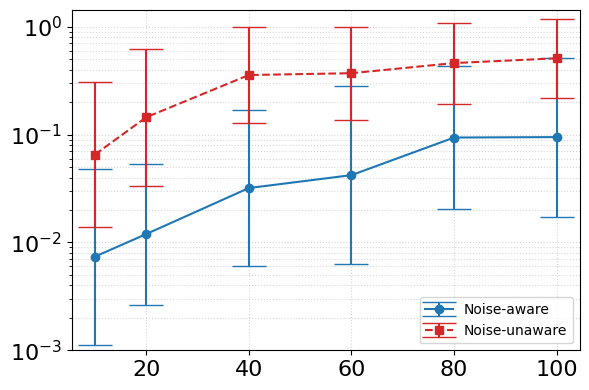

In [522]:
# Provided dictionaries
noise_aware = {
    10: '/Users/vishchaudhary/rl-repo/results/2025-06-25_16-01-14/RandomSU2/RandomSU2_env_data.csv',
    20: '/Users/vishchaudhary/rl-repo/results/2025-06-25_17-08-46/RandomSU2/RandomSU2_env_data.csv',
    40: '/Users/vishchaudhary/rl-repo/results/2025-06-25_18-13-32/RandomSU2/RandomSU2_env_data.csv',
    60: '/Users/vishchaudhary/rl-repo/results/2025-06-25_19-23-06/RandomSU2/RandomSU2_env_data.csv',
    80: '/Users/vishchaudhary/rl-repo/results/2025-06-25_22-55-50/RandomSU2/RandomSU2_env_data.csv',
    100: '/Users/vishchaudhary/rl-repo/results/2025-06-26_00-40-24/RandomSU2/RandomSU2_env_data.csv'
}
noise_unaware = {
    10: '/Users/vishchaudhary/rl-repo/results/2025-06-24_13-19-07/RandomSU2/RandomSU2_env_data.csv',
    20: '/Users/vishchaudhary/rl-repo/results/2025-06-24_14-25-54/RandomSU2/RandomSU2_env_data.csv',
    40: '/Users/vishchaudhary/rl-repo/results/2025-06-24_16-41-30/RandomSU2/RandomSU2_env_data.csv',
    60: '/Users/vishchaudhary/rl-repo/results/2025-06-25_12-56-44/RandomSU2/RandomSU2_env_data.csv',
    80: '/Users/vishchaudhary/rl-repo/results/2025-06-25_14-20-33/RandomSU2/RandomSU2_env_data.csv',
    100: '/Users/vishchaudhary/rl-repo/results/2025-07-10_01-02-16/RandomSU2/RandomSU2_env_data.csv'
}
noise_std_plot_logerr(noise_aware, noise_unaware, save_plot = False, save_dir='/Users/vishchaudhary/rl-repo/results/2025-03-26_03-13-38/noise_error_plot')

In [19]:
def inference_distribution_figure_2(infer_dir, baseline_dir, save_plot=False, save_dir = None):
    # ---------------------- Get Training Data  <--------------------------------------
    baseline_df = pd.read_csv(baseline_dir, header=0)
    baseline_fidelities      = np.array(baseline_df.iloc[:, 0])
    baseline_rewards         = np.array(baseline_df.iloc[:, 1])
    baseline_episode_ids     = np.array(baseline_df.iloc[:, -1])

    print("training_max fidelity: ", baseline_fidelities.max())
    print("training_max reward:   ", baseline_rewards.max())

    # --------> Final infidelity per episode (training) <--------
    baseline_final_fidelity_per_episode = []
    baseline_final_infelity_per_episode = []
    baseline_sum_of_rewards_per_episode = []

    current_episode_id = baseline_episode_ids[0]
    current_fidelity   = baseline_fidelities[0]
    current_reward_sum = baseline_rewards[0]
    for i in range(len(baseline_episode_ids)):
        if (baseline_episode_ids[i] != current_episode_id) or (i == len(baseline_episode_ids)-1):
            baseline_final_fidelity_per_episode.append(current_fidelity)
            baseline_final_infelity_per_episode.append(1 - current_fidelity)
            baseline_sum_of_rewards_per_episode.append(current_reward_sum)
            current_reward_sum = 0
        current_episode_id = baseline_episode_ids[i]
        current_fidelity   = baseline_fidelities[i]
        current_reward_sum += baseline_rewards[i]

    baseline_final_infelity_per_episode = np.array(baseline_final_infelity_per_episode)

    # ---------------------- Get Inference Data  <--------------------------------------
    infer_df        = pd.read_csv(infer_dir, header=0)
    infer_fidelities= np.array(infer_df.iloc[:, 0])
    inf_rewards   = np.array(infer_df.iloc[:, 1])


    # Compute infidelity per episode (inference)
    infer_infidelity = 1.0 - infer_fidelities

    print(f"Min baseline error: {baseline_final_infelity_per_episode.min()}")
    print(f"Max baseline error: {baseline_final_infelity_per_episode.max()}")
    print(f"Mean Baseline error: {baseline_final_infelity_per_episode.mean()}")
    print(f"Median Baseline error: { np.median(baseline_final_infelity_per_episode)}\n\n")
    print(f"Min Infer error:      {infer_infidelity.min()}")
    print(f"Max Infer error:      {infer_infidelity.max()}")
    print(f"Mean Infer error: {infer_infidelity.mean()}")
    print(f"Median infer error: {np.median(infer_infidelity)}")


    # ---------------------- Build log‐spaced bins -------------------------
    all_inf = np.concatenate([baseline_final_infelity_per_episode, infer_infidelity])
    min_inf = max(all_inf.min(), 1e-12)
    max_inf = all_inf.max()
    bins    = np.logspace(np.log10(min_inf), np.log10(max_inf), 100)

    # ---------------------- Convert counts to percentages -----------------
    weights_tr  = np.ones_like(baseline_final_infelity_per_episode) / baseline_final_infelity_per_episode.size * 100
    weights_inf = np.ones_like(infer_infidelity)                 / infer_infidelity.size                 * 100

    # ---------------------- Plot histograms -------------------------------
    plt.figure(figsize=(8, 5))
    plt.hist(baseline_final_infelity_per_episode,
             bins=bins,
             weights=weights_tr,
             alpha=0.6,
             label='Analytical Baseline',
             color='tab:red',
             edgecolor='black')
    plt.hist(infer_infidelity,
             bins=bins,
             weights=weights_inf,
             alpha=0.6,
             label='RL Agent',
             color='tab:blue',
             edgecolor='black')

    plt.xscale('log')
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    # plt.xlabel(r'$\epsilon$ (log scale)', fontsize=14, fontweight='bold')
    # plt.ylabel('Frequency (%)', fontsize=14, fontweight='bold')
    # plt.title('', fontsize=14, fontweight='bold')
    # plt.legend(fontsize=11)
    leg = plt.legend()               # no fontsize here…
    for txt in leg.get_texts():      # leg.get_texts() is a list of Text objects
        txt.set_fontsize(16)         # set each label’s font size
    plt.grid(True, which='both', ls=':', alpha=0.5)
    plt.tight_layout()

    if save_plot:
        plt.savefig(f"{save_dir}/error_histogram_comparison.png",
                    dpi=300, bbox_inches='tight')
        plt.close()
    else:
        plt.show()

training_max fidelity:  0.9908179104528748
training_max reward:    6.055932194117626
Min baseline error: 0.009182089547125183
Max baseline error: 0.9992228185920449
Mean Baseline error: 0.6838081445684874
Median Baseline error: 0.8143006691563013


Min Infer error:      0.010505412077155163
Max Infer error:      0.8040731984230896
Mean Infer error: 0.02693802382289492
Median infer error: 0.02448697263886057


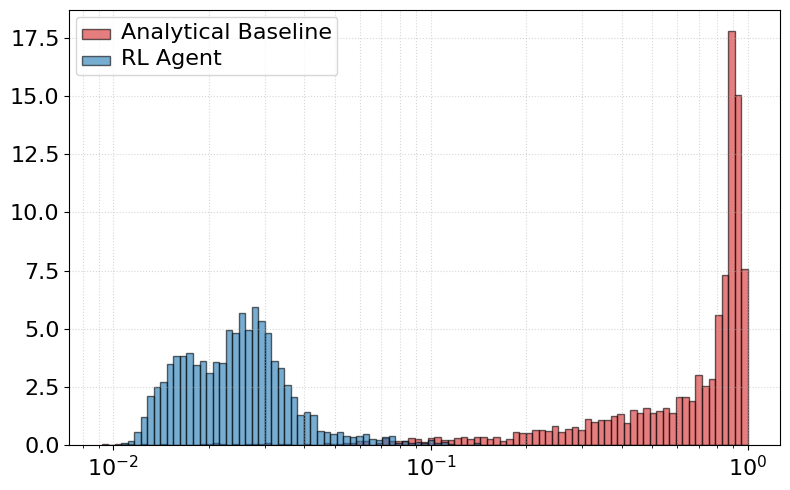

In [24]:
##TWO QUBIT
# inference_distribution_figure_2(infer_dir='/Users/vishchaudhary/rl-repo/results/two-qubit gates/2025-07-18_18-08-42/CNOT/CNOTenv_data.csv',
#                               baseline_dir= '/Users/vishchaudhary/rl-repo/results/two-qubit gates/2025-07-02_13-41-05/env_data.csv', save_plot = False, save_dir='/Users/vishchaudhary/rl-repo/results/two-qubit gates/2025-07-02_22-45-26/')

inference_distribution_figure_2(infer_dir='/Users/vishchaudhary/rl-repo/results/two-qubit gates/2025-07-02_22-45-26/CNOT/env_data.csv',
                              baseline_dir= '/Users/vishchaudhary/rl-repo/results/two-qubit gates/2025-07-03_22-05-28/env_data.csv', save_plot = False, save_dir='')

In [188]:
###Two Qubit
def training_figure_2(save_dir,
                    figure_title='',
                    plot_filename='plot',
                    perform_analysis=False,
                    save_plot=False):
    """Split into two publication‐quality figures:
       (a) 1–F (log scale) and (b) Sum of Rewards,
       with bold axis labels, darker ticks, and reduced x‐tick density."""
    # ---------------------- Load data --------------------------------------
    df = pd.read_csv(os.path.join(save_dir, "env_data.csv"), header=0)
    fidelities  = df.iloc[:, 0].values
    rewards     = df.iloc[:, 1].values
    episode_ids = df.iloc[:, -1].values

    if perform_analysis:
        perform_action_analysis(df=df)

    # --------> Final per-episode values -----------------------------------
    final_inf = []
    sum_rw    = []
    ep   = episode_ids[0]
    fid  = fidelities[0]
    acc  = rewards[0]
    for i in range(1, len(episode_ids)):
        if episode_ids[i] != ep:
            final_inf.append(1 - fid)
            sum_rw.append(acc)
            acc = 0
        ep  = episode_ids[i]
        fid = fidelities[i]
        acc += rewards[i]
    final_inf.append(1 - fid)
    sum_rw.append(acc)

    # ---------------------- Rolling averages --------------------------------
    window = 100
    def rolling_avg(x):
        return np.array([x[max(0, i-window):i+1].mean()
                         for i in range(len(x))])

    avg_inf = rolling_avg(np.array(final_inf))
    avg_rw  = rolling_avg(np.array(sum_rw))

    # ------------------------------ Plotting -------------------------------
    episodes = np.arange(len(final_inf))
    step     = 5

    # ----- Figure A: 1 - Fidelity (log scale) -----
    figA, axA = plt.subplots(figsize=(6, 4))
    axA.scatter(episodes[::step],
                final_inf[::step],
                s=5, alpha=0.3,
                color='tab:red',
                )
    axA.plot(episodes,
             avg_inf,
             color='black',
             linewidth=1.5,
             )
    axA.set_yscale('log')

    # bold, larger axis labels
    axA.set_xlabel('Episodes',
                   fontsize=14,
                   fontweight='bold')
    axA.set_ylabel('',
                   fontsize=14,
                   fontweight='bold')

    # darker, thicker ticks & limited x‐ticks
    axA.tick_params(axis='both',
                    which='major',
                    labelsize=12,
                    width=1.5,
                    length=6,
                    color='black')
    axA.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))

    # axA.legend(fontsize=10, loc='upper right')
    figA.suptitle('1 - Fidelity (log scale)',
                  fontsize=16,
                  fontweight='bold',
                  y=1.02)

    plt.tight_layout()
    if save_plot:
        figA.savefig(os.path.join(save_dir,
                                  f"{plot_filename}_infidelity.png"),
                     dpi=300, bbox_inches='tight')
        plt.close(figA)
    else:
        plt.show()


    # ----- Figure B: Sum of Rewards -----
    figB, axB = plt.subplots(figsize=(6, 4))
    axB.scatter(episodes[::step],
                sum_rw[::step],
                s=5, alpha=0.3,
                color='tab:blue',
                )
    axB.plot(episodes,
             avg_rw,
             color='black',
             linewidth=1.5,
             )

    # bold, larger axis labels
    axB.set_xlabel('Episodes',
                   fontsize=14,
                   fontweight='bold')
    axB.set_ylabel('',
                   fontsize=14,
                   fontweight='bold')

    # darker, thicker ticks & limited x‐ticks
    axB.tick_params(axis='both',
                    which='major',
                    labelsize=12,
                    width=1.5,
                    length=6,
                    color='black')
    axB.xaxis.set_major_locator(MaxNLocator(nbins=6, integer=True))

    # axB.legend(fontsize=10, loc='upper right')
    figB.suptitle('Sum of Rewards',
                  fontsize=16,
                  fontweight='bold',
                  y=1.02)

    plt.tight_layout()
    if save_plot:
        figB.savefig(os.path.join(save_dir,
                                  f"{plot_filename}_reward.png"),
                     dpi=300, bbox_inches='tight')
        plt.close(figB)
    else:
        plt.show()

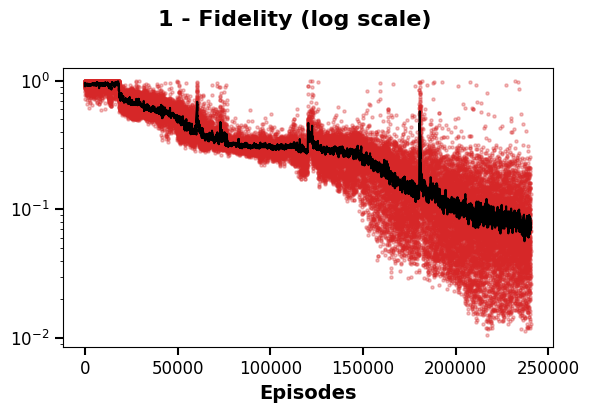

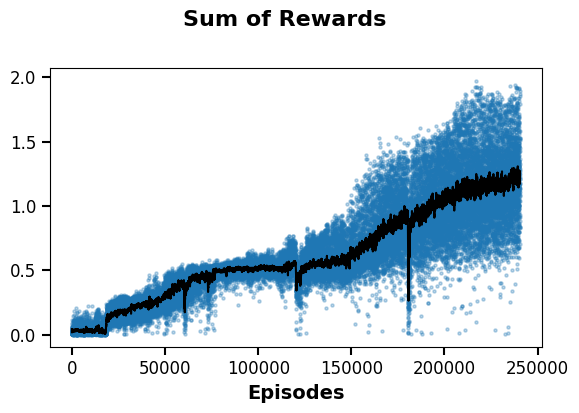

In [214]:
training_figure_2('/Users/vishchaudhary/rl-repo/results/two-qubit gates/combined_training_I_CNOT/', save_plot=True, plot_filename='Training_Fig_.png')

In [317]:
def stack_images_vertically(image_paths, show=True, save_path=None):
    """
    Stacks three images vertically.

    Parameters:
        image_paths (list of str): List of 3 image file paths.
        show (bool): Whether to display the stacked image.
        save_path (str or None): If provided, path to save the stacked image.
    """
    if len(image_paths) != 3:
        raise ValueError("Please provide exactly 3 image paths.")

    # Open images
    images = [Image.open(path) for path in image_paths]

    # Optionally resize to same width
    min_width = min(img.width for img in images)
    resized_images = [img.resize((min_width, int(img.height * min_width / img.width)))
                      for img in images]

    # Compute total height
    total_height = sum(img.height for img in resized_images)

    # Create new blank image
    combined_img = Image.new('RGB', (min_width, total_height), color=(255, 255, 255))

    # Paste images one below the other
    y_offset = 0
    for img in resized_images:
        combined_img.paste(img, (0, y_offset))
        y_offset += img.height

    # Show if requested
    if show:
        combined_img.show()

    # Save if path is given
    if save_path:
        combined_img.save(save_path, dpi=(300, 300))
        print(f"Saved combined image to {save_path}")

In [349]:
stack_img_paths = ["/Users/vishchaudhary/rl-repo/results/2025-03-26_03-13-38/Training_error.png",
                   "/Users/vishchaudhary/rl-repo/results/2025-03-26_03-13-38/Training_reward.png",
                   "/Users/vishchaudhary/rl-repo/results/2025-03-26_03-13-38/error_histogram_comparison.png"]

stack_images_vertically(stack_img_paths, show=False, save_path='/Users/vishchaudhary/rl-repo/results/2025-03-26_03-13-38/SU2_all_figures_combined.png')

Saved combined image to /Users/vishchaudhary/rl-repo/results/2025-03-26_03-13-38/SU2_all_figures_combined.png
